In [161]:
import os
import json
import csv

import matplotlib.pyplot as plt
from sankeyflow import Sankey

In [106]:
from cmat.clinvar_xml_io import ClinVarDataset
from cmat.clinvar_xml_io.filtering import filter_by_submission
from cmat.output_generation.clinvar_to_evidence_strings import load_ontology_mapping
from cmat.trait_mapping.ols import is_current_and_in_ontology

## Investigations for cleaning up trait mappings

1. [Mappings used in evidence](#Mappings-used-in-evidence)
2. [Origin of mappings used in evidence](#Origin-of-mappings-used-in-evidence)
3. [Preferred vs. all trait names](#Preferred-vs-all-trait-names)
4. [Zooma behaviour](#Zooma-behaviour)

In [87]:
def print_set(s, n=10):
    # Helper function to peek at large sets
    i = 0
    for x in s:
        print(x)
        i += 1
        if i > n:
            break

### Mappings used in evidence

[Top of page](#Investigations-for-cleaning-up-trait-mappings)

* How many mappings in the latest_mappings file are used in latest evidence strings / latest ClinVar?

In [22]:
# Get all trait names with EFO mappings from 2025.12 evidence
# To easily handle multiples we define a "mapping" as a pair: (trait_name, ontology_id)
# This mirrors how they're counted in the tsv files where each row is a mapping.

mappings_in_evidence = set()
with open(os.path.join(os.getenv('BATCH_ROOT'), 'batch-2025-12/evidence_strings/evidence_strings.json')) as f:
    for line in f:
        evidence = json.loads(line.strip())
        if evidence.get('diseaseFromSourceMappedId') and evidence.get('diseaseFromSource'):
            mappings_in_evidence.add((evidence.get('diseaseFromSource').lower(), evidence.get('diseaseFromSourceMappedId')))

The above method of getting used mappings does NOT work, due to [this quirk](https://github.com/EBIvariation/CMAT/issues/384) about how we annotate traits in ClinVar. For example:

```
$ grep -i 'focal facial dermal dysplasia type iii' trait_names_to_ontology_mappings.tsv
focal facial dermal dysplasia type iii  http://purl.obolibrary.org/obo/MONDO_0009203    focal facial dermal dysplasia type III
congenital ectodermal dysplasia of face http://www.orpha.net/ORDO/Orphanet_1807 Focal facial dermal dysplasia type III
focal facial dermal dysplasia 3, setleis type   http://www.orpha.net/ORDO/Orphanet_1807 Focal facial dermal dysplasia type III

$ grep -i 'focal facial dermal dysplasia type iii' batch-2025-12/evidence_strings/evidence_strings.json
<json abbreviated>
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III",
    "diseaseFromSourceId": "C1744559", 
    "diseaseFromSourceMappedId": "Orphanet_1807", ...}
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III", 
    "diseaseFromSourceId": "C1744559",
    "diseaseFromSourceMappedId": "Orphanet_398166", ...}
{..."cohortPhenotypes": ["BITEMPORAL FORCEPS MARKS SYNDROME", "FFDD type 2", "FOCAL FACIAL DERMAL DYSPLASIA, TYPE II", "Focal facial dermal dysplasia 3", "Focal facial dermal dysplasia 3, Setleis type", "Focal facial dermal dysplasia type III", "SETLEIS SYNDROME"],
    "diseaseFromSource": "Focal facial dermal dysplasia type III",
    "diseaseFromSourceId": "C1744559",
    "diseaseFromSourceMappedId": "MONDO_0009203", ...}
<more results>

# The other two mappings appear above, check the third
$ grep -i 'Orphanet_398166' trait_names_to_ontology_mappings.tsv
congenital ectodermal dysplasia of face http://www.orpha.net/ORDO/Orphanet_398166       Focal facial dermal dysplasia
focal facial dermal dysplasia 3, setleis type   http://www.orpha.net/ORDO/Orphanet_398166       Focal facial dermal dysplasia
```
Note that both [Orphanet_1807](https://www.ebi.ac.uk/ols4/ontologies/efo/classes/http%253A%252F%252Fwww.orpha.net%252FORDO%252FOrphanet_1807) and [Orphanet_398166](https://www.ebi.ac.uk/ols4/ontologies/efo/classes/http%253A%252F%252Fwww.orpha.net%252FORDO%252FOrphanet_398166) are deprecated in EFO, which is what Issue 384 is about.

This issue is a separate one from what we're investigating (though not using previous mappings would mitigate this as well). For the purposes of this investigation, the point is that these `(diseaseFromSource, diseaseFromSourceMappedId)` tuples are not actually the mappings we should be using for counts!

In [101]:
# Instead run an abridged version of the evidence string pipeline with only trait mappings
clinvar_xml = os.path.join(os.getenv('BATCH_ROOT'), 'batch-2025-12/clinvar/clinvar.xml.gz')
latest_mappings_file = os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/trait_names_to_ontology_mappings.tsv')

In [109]:
latest_mappings, _ = load_ontology_mapping(latest_mappings_file)

INFO:cmat.output_generation:15972 ontology mappings loaded for ontology EFO


In [198]:
mappings_in_evidence = {}

dataset = ClinVarDataset(clinvar_xml)
clinvar_total = 0
for clinvar_set in dataset.iter_cvs():
    clinvar_total += 1
    if clinvar_total % 100000 == 0:
        print(f'{clinvar_total} records processed')

    try:
        # Records skipped by evidence string pipeline
        if not filter_by_submission(clinvar_set):
            continue
        clinvar_record = clinvar_set.rcv
        
        if len(clinvar_record.clinical_classifications) > 1:
            continue
        if not clinvar_record.traits_with_valid_names:
            continue
        if not clinvar_record.valid_clinical_significances:
            continue
        if clinvar_record.measure is None:
            continue

        # Get EFO mappings
        for trait in clinvar_record.traits_with_valid_names:
            for trait_name in trait.all_names:
                for uri, label in latest_mappings.get(trait_name.lower(), []):
                    # Store the full URI and whether the trait name is preferred or not
                    mappings_in_evidence[(trait_name.lower(), uri.split('/')[-1])] = (uri, trait_name.lower() == trait.preferred_or_other_valid_name.lower())

    except Exception as e:
        print(f'Problem getting mappings for {clinvar_set.rcv.accession}: {repr(e)}')
        continue
        
print(f'{clinvar_total} records processed')

100000 records processed
200000 records processed
300000 records processed
400000 records processed
500000 records processed
600000 records processed
700000 records processed
800000 records processed
900000 records processed
1000000 records processed
1100000 records processed
1200000 records processed
1300000 records processed
1400000 records processed
1500000 records processed
1600000 records processed
1700000 records processed
1800000 records processed
1900000 records processed
2000000 records processed
2100000 records processed
2200000 records processed
2300000 records processed
2400000 records processed
2500000 records processed
2600000 records processed
2700000 records processed
2800000 records processed
2900000 records processed
3000000 records processed
3100000 records processed
3200000 records processed
3300000 records processed
3400000 records processed
3500000 records processed
3600000 records processed
3700000 records processed
3800000 records processed
3900000 records proce

In [118]:
# Dump mappings_in_evidence so we don't need to rerun
with open('mappings_in_evidence.csv', 'w') as f:
    writer = csv.writer(f, delimiter=',')
    for row in mappings_in_evidence:
        writer.writerow(row)

In [201]:
len(mappings_in_evidence)

13689

In [199]:
!wc -l ${BATCH_ROOT}/manual_curation/latest_mappings.tsv

15975 /nfs/production/keane/eva/opentargets/manual_curation/latest_mappings.tsv


In [121]:
# Percentage of mappings being used in latest evidence
13689/15975

0.8569014084507042

### Origin of mappings used in evidence

[Top of page](#Investigations-for-cleaning-up-trait-mappings)

* How many mappings are being used but are bypassing curation completely (high confidence from Zooma or exact match from OLS)?
* Are there any mappings that are used in evidence strings but aren’t in the most recent curated and automated mappings?

In [128]:
# Check where these mappings come from: most recent automated mappings, most recent manual curation, or neither

# Use a dict so we can hash on (trait_name, ontology_id), but keep the URI to check obsoleteness
automated_mappings = {}
with open(os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/automated_trait_mappings.tsv')) as f:
    for line in f:
        trait_name, ontology_uri, ontology_label = line.strip().split('\t')
        automated_mappings[(trait_name.lower(), ontology_uri.split('/')[-1])] = ontology_uri

In [129]:
len(automated_mappings)

11075

In [130]:
curated_mappings = {}
with open(os.path.join(os.getenv('BATCH_ROOT'), 'manual_curation/2025-10-02/finished_curation_spreadsheet.csv')) as f:
    reader = csv.reader(f, dialect='excel')
    # skip header
    next(reader)
    next(reader)
    for row in reader:
        if row[5] == 'DONE' and row[0] and row[7]:
            curated_mappings[(row[7].lower(), row[0].split('/')[-1])] = row[0]

In [131]:
len(curated_mappings)

371

In [133]:
# Mappings in latest carried over from previous (not from automated or curated)
15975 - (11075 + 371)

4529

In [134]:
mappings_used_in_automated = set()
mappings_used_in_curated = set()
mappings_used_in_neither = set()  # these are "previous mappings" only
mappings_used_in_both = set()  # sanity check - this should never happen!

for mapping in mappings_in_evidence:
    if mapping in automated_mappings and mapping not in curated_mappings:
        mappings_used_in_automated.add(mapping)
    if mapping not in automated_mappings and mapping in curated_mappings:
        mappings_used_in_curated.add(mapping)
    if mapping in automated_mappings and mapping in curated_mappings:
        mappings_used_in_both.add(mapping)
    if mapping not in automated_mappings and mapping not in curated_mappings:
        mappings_used_in_neither.add(mapping)

In [135]:
len(mappings_used_in_automated)

11059

In [136]:
len(mappings_used_in_curated)

366

In [140]:
len(mappings_used_in_neither)

2264

In [141]:
len(mappings_used_in_both)

0

In [142]:
# Confirm these add up to the number of mappings used in the evidence
11059 + 366 + 2264

13689

* How many mappings in each of these categories (automated, curated, or previous) are obsolete?

In [151]:
def get_num_obsolete(mapping_set):
    num_obsolete = 0
    for mapping in mapping_set:
        if not is_current_and_in_ontology(mappings_in_evidence[mapping]):
            num_obsolete += 1
    return num_obsolete       

In [192]:
# Note these are from a couple months ago, so it's expected that a handful will have been deprecated since then
get_num_obsolete(mappings_used_in_automated)

13

In [153]:
get_num_obsolete(mappings_used_in_curated)

3

In [154]:
get_num_obsolete(mappings_used_in_neither)

717

In [157]:
# Number of current EFO mappings used in the current evidence that are only present in previous mappings,
# i.e. not in the latest automated or curated mappings.
2264-717

1547

This exceeds the 716 multiple mappings found previously, so these can't all be duplicate terms. The question is, where are these coming from and why are they not present in Zooma or automated mappings more generally?

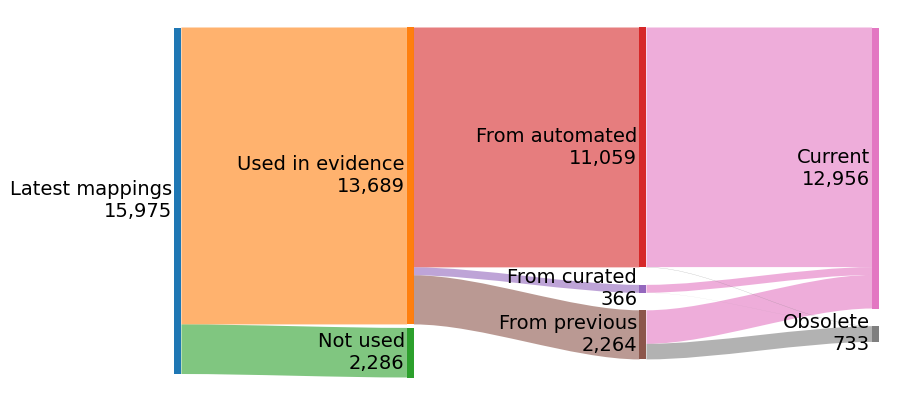

In [173]:
# Visualise what we have so far
plt.figure(figsize=(10, 5))
flows = [
    ('Latest mappings', 'Used in evidence', 13689),
    ('Latest mappings', 'Not used', 15975-13689),
    ('Used in evidence', 'From automated', 11059),
    ('Used in evidence', 'From curated', 366),
    ('Used in evidence', 'From previous', 2264),
    ('From automated', 'Current', 11059-13),
    ('From curated', 'Current', 366-3),
    ('From previous', 'Current', 2264-717),
    ('From automated', 'Obsolete', 13),
    ('From curated', 'Obsolete', 3),
    ('From previous', 'Obsolete', 717),
]
s = Sankey(flows=flows)
s.draw()
plt.show()

In [175]:
# Filter mappings_used_in_neither to remove obsolete mappings and terms that are present in automated or curated
# The latter should in the future be "overwritten" by the automated and curated mappings in each round

automated_trait_names = {trait_name for trait_name, ontology_id in mappings_used_in_automated}
curated_trait_names = {trait_name for trait_name, ontology_id in mappings_used_in_curated}

In [178]:
previous_mappings_for_distinct_traits = set()
for mapping in mappings_used_in_neither:
    if is_current_and_in_ontology(mappings_in_evidence[mapping][0]):
        trait_name = mapping[0]
        if trait_name not in automated_trait_names and trait_name not in curated_trait_names:
            previous_mappings_for_distinct_traits.add(mapping)

In [181]:
len(previous_mappings_for_distinct_traits)

1546

These are mappings that:
1. Do not appear in the most recent automated and curated mappings
2. Are used the most recent evidence strings
2. Are not obsolete
3. Are not for traits that appear in the automated/curated mappings

In [182]:
with open('suspicious_mappings.csv', 'w') as f:
    writer = csv.writer(f, delimiter=',')
    for row in previous_mappings_for_distinct_traits:
        writer.writerow(row)

An example mapping here is `dystonia` => `HP_0001332`, which is an exact match via OLS and thus should be an automated mapping. (It's also a high confidence mapping from Zooma, but that might be affected by the Zooma feedback we've imported since the curation happened.)

So the only reason this wouldn't show up in automated mappings is if it appeared among all trait names (used for evidence generation) but NOT among preferred trait names (used for generating automated and curated mappings) - or (less likely), if it appeared in the version of ClinVar used for evidence generation but NOT the version of ClinVar used for generating mappings and curation.

My main conclusion from this is that barring some unusual behaviour from Zooma, there is no need to keep previous mappings as long as we either attempt to map all trait names, or only annotate preferred trait names.

Below we check both Zooma behaviour as well as the preferred vs. all trait name hypothesis.

### Preferred vs. all trait names

[Top of page](#Investigations-for-cleaning-up-trait-mappings)

* Are previous mappings being used in evidence because annotations are being done with all trait names rather than just preferred?

In [204]:
# Filter for previous mappings applied to preferred names only
previous_preferred_mappings = set()
for mapping in previous_mappings_for_distinct_traits:
    if mappings_in_evidence[mapping][1]:
        previous_preferred_mappings.add(mapping)

In [205]:
len(previous_preferred_mappings)

469

In [206]:
print_set(previous_preferred_mappings)

('posterior polymorphous corneal dystrophy 3', 'MONDO_0020364')
('hyperhomocysteinemia, thrombotic, cbs-related', 'Orphanet_394')
('trichoepithelioma, multiple familial, 1', 'MONDO_0011512')
('immunodeficiency 65, susceptibility to viral infections', 'MONDO_0021094')
('sitosterolemia 1', 'MONDO_0008863')
('psoriasis 1, susceptibility to', 'EFO_0000676')
('intellectual disability, anterior maxillary protrusion, and strabismus', 'HP_0001249')
('metaphyseal chondrodysplasia', 'MONDO_0009597')
('myopathy, congenital, with structured cores and z-line abnormalities', 'MONDO_0019952')
('intellectual disability, autosomal dominant 46', 'MONDO_0015802')
('nephronophthisis 20', 'MONDO_0019005')


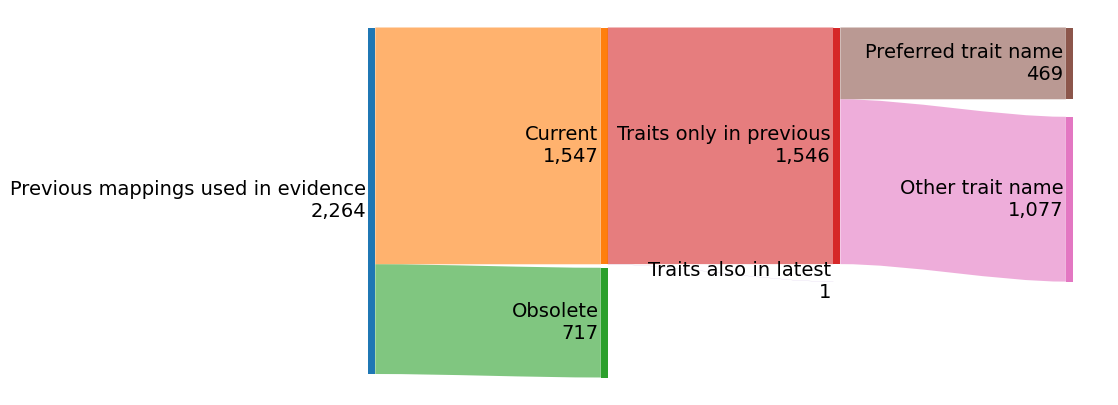

In [210]:
# Visualise what we have so far
plt.figure(figsize=(10, 5))
flows = [
    ('Previous mappings used in evidence', 'Current', 1547),
    ('Previous mappings used in evidence', 'Obsolete', 717),
    ('Current', 'Traits only in previous',  1546),
    ('Current', 'Traits also in latest', 1),
    ('Traits only in previous', 'Preferred trait name', 469),
    ('Traits only in previous', 'Other trait name', 1546-469),
]
s = Sankey(flows=flows)
s.draw()
plt.show()

In fact there are still preferred trait names who get their mappings only from previous mappings, not automated or curated. So while aligning the sets of trait names we map vs. annotate would help with a lot of issues, it doesn't remove the need to keep our memory of previous mappings

### Zooma behaviour

[Top of page](#Investigations-for-cleaning-up-trait-mappings)

* Are there mappings that used to be high confidence in automated mapping and subsequently were mapped with low confidence?

In [183]:
!ls $BATCH_ROOT/manual_curation

2022-02-03_test  2023-05-26_test    2024-07-02	     2025-10-02
2022-03-03	 2023-06-06	    2024-09-05_test  eva_clinvar.txt
2022-05-11	 2023-06-06_counts  2024-10-11	     latest_comments.tsv
2022-08-18	 2023-07-24	    2025-01-16	     latest_mappings.tsv
2022-10-17_test  2023-10-03	    2025-02-25_test
2023-01-09	 2024-01-19	    2025-04-15
2023-03-01	 2024-04-11	    2025-06-20


In [195]:
# Start with first date that uses current spreadsheet export method
dates = ['2023-01-09', '2023-03-01', '2023-06-06', '2023-07-24', '2023-10-03', 
         '2024-01-19', '2024-04-11', '2024-07-02', '2024-10-11', 
         '2025-01-16', '2025-04-15', '2025-06-20', '2025-10-02']

In [196]:
# Check past batches for terms that move from automated mappings to mappings for curation
automated_terms_through_time = []
curated_terms_through_time = []

for date in dates:
    automated_terms = set()
    with open(os.path.join(os.getenv('BATCH_ROOT'), f'manual_curation/{date}/automated_trait_mappings.tsv')) as f:
        for line in f:
            trait_name, ontology_uri, ontology_label = line.strip().split('\t')
            automated_terms.add(trait_name)
    curated_terms = set()
    with open(os.path.join(os.getenv('BATCH_ROOT'), f'manual_curation/{date}/finished_curation_spreadsheet.csv')) as f:
        reader = csv.reader(f, dialect='excel')
        # skip header
        next(reader)
        next(reader)
        for row in reader:
            if row[5] == 'DONE' and row[0] and row[7]:
                curated_terms.add(row[7].lower())
    automated_terms_through_time.append(automated_terms)
    curated_terms_through_time.append(curated_terms)

In [197]:
for i in range(1, len(dates)):
    moved_terms = automated_terms_through_time[i-1].intersection(curated_terms_through_time[i])
    if moved_terms:
        print(f'Following terms were automated in {dates[i-1]} but curated in {dates[i]}:')
        print(moved_terms)
        print()

Following terms were automated in 2023-06-06 but curated in 2023-07-24:
{'orofacial cleft 7', 'heterotaxy', 'spinocerebellar ataxia 7', 'qualitative or quantitative defects of beta-myosin heavy chain (myh7)', 'spheroid body myopathy', 'infantile hypercalcemia'}

Following terms were automated in 2023-07-24 but curated in 2023-10-03:
{'multisystemic smooth muscle dysfunction syndrome', 'li-fraumeni syndrome 1'}

Following terms were automated in 2023-10-03 but curated in 2024-01-19:
{'qualitative or quantitative defects of calpain', 'severe myoclonic epilepsy in infancy', 'dilated cardiomyopathy 1kk', 'dilated cardiomyopathy 1m', 'hereditary angioedema with normal c1inh', 'dilated cardiomyopathy 1gg', 'congenital myopathy with cores', 'apolipoprotein a-i (munster3b)', 'isolated anorectal malformation', 'non-syndromic renal or urinary tract malformation', 'dilated cardiomyopathy 1e', 'dilated cardiomyopathy 1ee', 'dilated cardiomyopathy 1aa', 'qualitative or quantitative defects of meros

Manually checked some of these by searching for them in the relevant curation spreadsheet and seeing how they were annotated there. Some findings:

* Besides June and October 2025, most of the above traits that I've checked manually were moved from automated to needing curation due to mappings being deprecated.
    * This includes the large batch in January 2024, which I believe is when EFO did some large-scale deprecations (I haven't checked all these terms though).
    * A notable exception is `qualitative or quantitative defects of beta-myosin heavy chain (myh7)` => `MONDO_0016195`, which was automated in 2023-06-06 but [curated in 2023-07-24](https://docs.google.com/spreadsheets/d/1IYfPY_K0aPsVwH9usVb2U2eUft1_yls5RWXxy-lq1SU/edit?gid=88027652#gid=88027652&range=6100:6100), at which point it was given the same mapping as previous. This is when the spreadsheet still reported Zooma confidence, so we can see explicitly that the Zooma confidence for the mapping was `GOOD` rather than `HIGH`.
    * The July 2023 curation spreadsheet provides a good example of what I remember seeing: lots of previous mappings which are still going through curation with Zooma confidence `GOOD`. I don't understand why this would be the case, maybe a Zooma issue?
        * One example is `nephronophthisis` which disappears from automated mappings throughout 2023 despite always being present in our final latest_mappings file:

```
$ grep -Pie '^nephronophthisis\t' */automated_trait_mappings.tsv 
2022-02-03_test/automated_trait_mappings.tsv:nephronophthisis   http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-03-03/automated_trait_mappings.tsv:nephronophthisis        http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-05-11/automated_trait_mappings.tsv:nephronophthisis        http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-08-18/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2022-10-17_test/automated_trait_mappings.tsv:nephronophthisis   http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-01-19/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-04-11/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-07-02/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-09-05_test/automated_trait_mappings.tsv:nephronophthisis   http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-10-11/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-01-16/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-02-25_test/automated_trait_mappings.tsv:nephronophthisis   http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-04-15/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-06-20/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-06-20/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/HP_0000090       Nephronophthisis
2025-10-02/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/HP_0000090       Nephronophthisis
2025-10-02/automated_trait_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis

$ grep -Pie '^nephronophthisis\t' */trait_names_to_ontology_mappings.tsv
2022-02-03_test/trait_names_to_ontology_mappings.tsv:nephronophthisis   http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-03-03/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-05-11/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://www.orpha.net/ORDO/Orphanet_655  Nephronophthisis
2022-08-18/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2022-10-17_test/trait_names_to_ontology_mappings.tsv:nephronophthisis   http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-01-09/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-03-01/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-05-26_test/trait_names_to_ontology_mappings.tsv:nephronophthisis   http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-06-06/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-07-24/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2023-10-03/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-01-19/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-04-11/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-07-02/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2024-10-11/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-01-16/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-04-15/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-06-20/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/HP_0000090       Nephronophthisis
2025-06-20/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
2025-10-02/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/HP_0000090       Nephronophthisis
2025-10-02/trait_names_to_ontology_mappings.tsv:nephronophthisis        http://purl.obolibrary.org/obo/MONDO_0019005    nephronophthisis
```

* For June and October 2025, most mappings I've checked were NOT deprecated, but returned to needing curation for an unknown reason. Since the spreadsheet no longer reports Zooma confidence, we can't confirm what the Zooma confidence was at the time of spreadsheet generation, since we've now provided Zooma feedback for the October batch and it may be incorporated already.
    * For example, `severe cystic degeneration of the brain` => `HP_0007313`, which was an automated mapping through 2025-06-20 but had to go through [curation in 2025-10-02](https://docs.google.com/spreadsheets/d/1dYIHJ4QfC8cjCwJFzXnYzLglmg2V7h4wIicRqIVqxdg/edit?gid=88027652#gid=88027652&range=6279:6279), at which point it was given the same mapping as previous.
    * Around June 2025 was the major revamp of the manual curation pipeline ([see PR](https://github.com/EBIvariation/CMAT/pull/465)), so maybe the influx of "previously automated, now curated" terms indicates an issue in the new pipeline. We should definitely look into this.
    
Basically, my conclusion here is that due to a potential problem in the new pipeline, as well as uncertainty around how Zooma behaves and how reliable it is, we should for now maintain our memory of previous mappings including automated ones, and not rely solely on Zooma for this.